# Selección del mejor modelo

**Autora:** Leydy Osorio Vargas  
**Fecha:** 2026-09-08

## Descripción

Este notebook corresponde a la Tarea 6. Compara cuatro familias de clasificación mediante validación cruzada, elimina el candidato con desempeño inferior al promedio, optimiza tres finalistas y selecciona el ganador con **recall** como métrica principal. La especificidad, precisión, F1, balanced accuracy y ROC AUC se conservan como métricas de control.

El conjunto de prueba permanece aislado hasta terminar la selección. El pipeline ganador incorpora la ingeniería de atributos de la Tarea 4 y se persiste completo en formato `joblib`.


## Alcance y decisiones analíticas

- Se reutiliza `data/02_intermediate/corazon_type_fixed.parquet`.
- Se eliminan filas exactamente duplicadas antes de dividir para impedir que una copia aparezca en entrenamiento y otra en prueba.
- Se excluyen únicamente las filas sin etiqueta; la imputación de predictores ocurre dentro de cada fold.
- La partición estratificada 80/20 y la semilla 42 son las mismas de la Tarea 5.
- La prueba final se consulta una sola vez, después de elegir el modelo por validación cruzada.
- Este análisis apoya un ejercicio académico y no constituye una herramienta diagnóstica.


## 📚 Importar librerías y configurar reproducibilidad


In [1]:
import sys
import warnings
from itertools import combinations
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from scipy.stats import friedmanchisquare, wilcoxon
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    make_scorer,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    learning_curve,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
TEST_SIZE = 0.20
CV_FOLDS = 5
PARALLEL_JOBS = 1
MIN_MODEL_FAMILIES = 4
MIN_FINALISTS = 3
LEARNING_CURVE_POINTS = 5
ALPHA = 0.05
TARGET = "disease"
POSITIVE_CLASS = 1
NEGATIVE_CLASS = 0

print(f"Pandas: {pd.__version__}")
print(f"Scikit-learn: {sklearn.__version__}")
print(f"Joblib: {joblib.__version__}")

Pandas: 3.0.5
Scikit-learn: 1.9.0
Joblib: 1.6.0


## 💾 Cargar y preparar los datos


In [2]:
PROJECT_DIR = Path.cwd().resolve()

if not (PROJECT_DIR / "data").is_dir():
    PROJECT_DIR = next(
        parent
        for parent in PROJECT_DIR.parents
        if (parent / "data").is_dir() and (parent / "pyproject.toml").exists()
    )

SRC_DIR = PROJECT_DIR / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from heart_project import HeartFeatureEngineer  # noqa: E402

INTERMEDIATE_FILE = PROJECT_DIR / "data" / "02_intermediate" / "corazon_type_fixed.parquet"
MODEL_FILE = PROJECT_DIR / "models" / "heart_disease_best_pipeline.joblib"

if not INTERMEDIATE_FILE.exists():
    raise FileNotFoundError("No se encontró el Parquet intermedio. Ejecute primero la Tarea 2.")

heart_df = pd.read_parquet(INTERMEDIATE_FILE)
unique_df = heart_df.drop_duplicates().copy()
unlabeled_df = unique_df.loc[unique_df[TARGET].isna()].copy()
modeling_df = unique_df.loc[unique_df[TARGET].notna()].copy()

pd.DataFrame(
    {
        "rows": [
            len(heart_df),
            int(heart_df.duplicated().sum()),
            len(unique_df),
            len(unlabeled_df),
            len(modeling_df),
        ]
    },
    index=[
        "original_rows",
        "exact_duplicates_removed",
        "unique_rows",
        "unique_rows_without_target",
        "rows_available_for_modeling",
    ],
)

,rows
original_rows,3030
exact_duplicates_removed,2462
unique_rows,568
unique_rows_without_target,88
rows_available_for_modeling,480


## ✂️ Mantener un conjunto de prueba independiente


In [3]:
X = modeling_df.drop(columns=TARGET)
y = modeling_df[TARGET].astype("int8")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

train_hashes = set(pd.util.hash_pandas_object(X_train.astype("string"), index=False))
test_hashes = set(pd.util.hash_pandas_object(X_test.astype("string"), index=False))

split_summary = pd.DataFrame(
    {
        "rows": [len(X_train), len(X_test)],
        "positive_rate_pct": [y_train.mean() * 100, y_test.mean() * 100],
    },
    index=["train", "test"],
)

assert X_train.index.intersection(X_test.index).empty
assert not train_hashes.intersection(test_hashes)
assert set(y.unique()) == {NEGATIVE_CLASS, POSITIVE_CLASS}

split_summary.round(2)

,rows,positive_rate_pct
train,384,47.92
test,96,47.92


## 🧱 Reconstruir el pipeline de Feature Engineering

El transformador personalizado se encuentra en `src/heart_project/transformers.py`, de modo que el objeto serializado pueda volver a cargarse fuera de este notebook. Todos los pasos que aprenden estadísticas se ajustan exclusivamente con los datos de entrenamiento de cada fold.


In [4]:
numeric_features = [
    "age",
    "rest_bp",
    "chol",
    "max_hr",
    "old_peak",
    "ca",
    "age_squared",
    "old_peak_slope_interaction",
    "max_hr_old_peak_interaction",
]
binary_features = ["fbs", "exang"]
ordinal_features = ["slope"]
nominal_features = [
    "sex",
    "chest_pain",
    "rest_ecg",
    "thal",
    "chest_pain_exang",
]

numeric_pipeline = Pipeline(
    [
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True,
                keep_empty_features=True,
            ),
        ),
        ("scaler", RobustScaler()),
    ]
)
binary_pipeline = Pipeline(
    [("imputer", SimpleImputer(strategy="most_frequent", keep_empty_features=True))]
)
ordinal_pipeline = Pipeline(
    [("imputer", SimpleImputer(strategy="most_frequent", keep_empty_features=True))]
)
nominal_pipeline = Pipeline(
    [
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="missing",
                keep_empty_features=True,
            ),
        ),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    [
        ("numeric", numeric_pipeline, numeric_features),
        ("binary", binary_pipeline, binary_features),
        ("ordinal", ordinal_pipeline, ordinal_features),
        ("nominal", nominal_pipeline, nominal_features),
    ],
    remainder="drop",
    verbose_feature_names_out=True,
)

feature_pipeline = Pipeline(
    [
        ("feature_engineering", HeartFeatureEngineer()),
        ("preprocessor", preprocessor),
    ]
)

feature_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('feature_engineering', ...), ('preprocessor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('binary', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold

## 📏 Definir métricas y validación cruzada


In [5]:
specificity_scorer = make_scorer(recall_score, pos_label=NEGATIVE_CLASS)
scoring = {
    "recall": "recall",
    "specificity": specificity_scorer,
    "precision": "precision",
    "f1": "f1",
    "balanced_accuracy": "balanced_accuracy",
    "roc_auc": "roc_auc",
}
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

baseline_reference = pd.Series(
    {
        "recall": 0.8478,
        "specificity": 0.6800,
        "precision": 0.7091,
        "f1": 0.7723,
        "balanced_accuracy": 0.7639,
        "roc_auc": 0.7639,
    },
    name="Baseline Tarea 5 (test)",
)

baseline_reference.to_frame().T

,recall,specificity,precision,f1,balanced_accuracy,roc_auc
Baseline Tarea 5 (test),0.8478,0.68,0.7091,0.7723,0.7639,0.7639


## 1. Comparación inicial de cuatro familias

Se comparan modelos lineales, ensambles de árboles, boosting y máquinas de vectores de soporte. Esta etapa usa configuraciones razonables, pero todavía no optimizadas.


In [6]:
initial_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        solver="liblinear",
        random_state=RANDOM_STATE,
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        min_samples_leaf=2,
        class_weight="balanced",
        n_jobs=PARALLEL_JOBS,
        random_state=RANDOM_STATE,
    ),
    "Histogram Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=200,
        learning_rate=0.05,
        l2_regularization=1.0,
        random_state=RANDOM_STATE,
    ),
    "Support Vector Machine": SVC(
        C=1.0,
        kernel="rbf",
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),
}

initial_cv_results = {}
for model_name, model in initial_models.items():
    candidate = Pipeline([("features", clone(feature_pipeline)), ("model", clone(model))])
    initial_cv_results[model_name] = cross_validate(
        candidate,
        X_train,
        y_train,
        scoring=scoring,
        cv=cv,
        n_jobs=PARALLEL_JOBS,
        return_train_score=True,
    )

initial_rows = []
for model_name, scores in initial_cv_results.items():
    row = {"model": model_name}
    for metric in scoring:
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()
    row["train_recall_mean"] = scores["train_recall"].mean()
    row["fit_time_mean_sec"] = scores["fit_time"].mean()
    initial_rows.append(row)

initial_comparison = (
    pd.DataFrame(initial_rows)
    .set_index("model")
    .sort_values(["recall_mean", "balanced_accuracy_mean"], ascending=False)
)

initial_comparison.round(4)

,recall_mean,recall_std,specificity_mean,specificity_std,precision_mean,precision_std,f1_mean,f1_std,balanced_accuracy_mean,balanced_accuracy_std,roc_auc_mean,roc_auc_std,train_recall_mean,fit_time_mean_sec
model,,,,,,,,,,,,,,
Random Forest,0.8156,0.0785,0.825,0.0962,0.8223,0.0686,0.8127,0.0203,0.8203,0.0207,0.9173,0.0206,0.9783,0.8884
Histogram Gradient Boosting,0.8044,0.0844,0.830,0.0485,0.8156,0.0336,0.8068,0.0414,0.8172,0.0323,0.9109,0.0276,0.9946,5.0502
Support Vector Machine,0.7992,0.0941,0.835,0.0943,0.8258,0.0736,0.8066,0.0555,0.8171,0.0491,0.9017,0.0320,0.8927,0.0682
Logistic Regression,0.7772,0.0523,0.845,0.0660,0.8283,0.0493,0.7987,0.0058,0.8111,0.0082,0.9010,0.0251,0.8451,0.1068


In [7]:
mean_candidate_recall = initial_comparison["recall_mean"].mean()
finalist_names = initial_comparison.index[
    initial_comparison["recall_mean"] >= mean_candidate_recall
].tolist()

if len(finalist_names) < MIN_FINALISTS:
    finalist_names = initial_comparison.head(MIN_FINALISTS).index.tolist()

eliminated_names = [name for name in initial_models if name not in finalist_names]

screening_summary = pd.Series(
    {
        "average_candidate_recall": mean_candidate_recall,
        "finalists": ", ".join(finalist_names),
        "eliminated_below_average": ", ".join(eliminated_names),
    }
)

screening_summary

average_candidate_recall                                             0.799099
finalists                   Random Forest, Histogram Gradient Boosting, Su...
eliminated_below_average                                  Logistic Regression
dtype: object

La regresión logística queda por debajo del recall promedio de los cuatro candidatos. Los otros tres modelos pasan a optimización. La regla se definió antes de consultar el test y evita gastar búsqueda en el candidato más débil.


## 2. Optimizar los tres finalistas


In [8]:
tuning_specs = {
    "Random Forest": (
        RandomForestClassifier(
            class_weight="balanced",
            n_jobs=PARALLEL_JOBS,
            random_state=RANDOM_STATE,
        ),
        {
            "model__n_estimators": [250, 500],
            "model__max_depth": [None, 6],
            "model__min_samples_leaf": [1, 3, 5],
        },
    ),
    "Histogram Gradient Boosting": (
        HistGradientBoostingClassifier(max_iter=200, random_state=RANDOM_STATE),
        {
            "model__learning_rate": [0.03, 0.07, 0.12],
            "model__max_leaf_nodes": [7, 15],
            "model__l2_regularization": [0.0, 1.0],
        },
    ),
    "Support Vector Machine": (
        SVC(kernel="rbf", class_weight="balanced", random_state=RANDOM_STATE),
        {
            "model__C": [0.1, 0.5, 1.0, 5.0],
            "model__gamma": ["scale", 0.01, 0.1],
        },
    ),
}

searches = {}
tuned_estimators = {}
tuned_cv_results = {}

for model_name in finalist_names:
    model, param_grid = tuning_specs[model_name]
    full_pipeline = Pipeline([("features", clone(feature_pipeline)), ("model", clone(model))])
    search = GridSearchCV(
        full_pipeline,
        param_grid=param_grid,
        scoring=scoring,
        refit="recall",
        cv=cv,
        n_jobs=PARALLEL_JOBS,
        return_train_score=True,
    )
    search.fit(X_train, y_train)
    searches[model_name] = search
    tuned_estimators[model_name] = search.best_estimator_
    tuned_cv_results[model_name] = cross_validate(
        search.best_estimator_,
        X_train,
        y_train,
        scoring=scoring,
        cv=cv,
        n_jobs=PARALLEL_JOBS,
        return_train_score=True,
    )

print("Optimización finalizada sin utilizar el conjunto de prueba.")

Optimización finalizada sin utilizar el conjunto de prueba.


In [9]:
tuned_rows = []
for model_name, scores in tuned_cv_results.items():
    row = {
        "model": model_name,
        "best_parameters": searches[model_name].best_params_,
        "train_recall_mean": scores["train_recall"].mean(),
        "recall_mean": scores["test_recall"].mean(),
        "recall_std": scores["test_recall"].std(),
        "balanced_accuracy_mean": scores["test_balanced_accuracy"].mean(),
        "f1_mean": scores["test_f1"].mean(),
        "roc_auc_mean": scores["test_roc_auc"].mean(),
        "fit_time_mean_sec": scores["fit_time"].mean(),
    }
    row["recall_generalization_gap"] = row["train_recall_mean"] - row["recall_mean"]
    tuned_rows.append(row)

tuned_comparison = (
    pd.DataFrame(tuned_rows)
    .set_index("model")
    .sort_values(["recall_mean", "balanced_accuracy_mean"], ascending=False)
)

tuned_comparison.round(4)

,best_parameters,train_recall_mean,recall_mean,recall_std,balanced_accuracy_mean,f1_mean,roc_auc_mean,fit_time_mean_sec,recall_generalization_gap
model,,,,,,,,,
Random Forest,"{'model__max_depth': None, 'model__min_samples...",0.9497,0.8374,0.0740,0.8237,0.8193,0.9180,0.5113,0.1123
Support Vector Machine,"{'model__C': 0.1, 'model__gamma': 0.1}",0.8682,0.8318,0.0517,0.8159,0.8126,0.8928,0.0474,0.0364
Histogram Gradient Boosting,"{'model__l2_regularization': 0.0, 'model__lear...",0.9851,0.8207,0.0735,0.8154,0.8089,0.9100,0.7825,0.1643


Random Forest consigue el mayor recall y balanced accuracy medios. SVM queda muy cerca y presenta una brecha menor entre entrenamiento y validación. Gradient Boosting muestra la brecha más grande, señal de mayor sobreajuste relativo. Estas diferencias se examinan estadísticamente antes de seleccionar.


## 3. Comparación estadística de los finalistas


In [10]:
recall_by_model = {name: tuned_cv_results[name]["test_recall"] for name in finalist_names}
friedman_statistic, friedman_p_value = friedmanchisquare(*recall_by_model.values())

pairwise_rows = []
for first_model, second_model in combinations(finalist_names, 2):
    statistic, p_value = wilcoxon(
        recall_by_model[first_model],
        recall_by_model[second_model],
        zero_method="zsplit",
    )
    pairwise_rows.append(
        {
            "comparison": f"{first_model} vs {second_model}",
            "statistic": statistic,
            "p_value": p_value,
        }
    )

pairwise_tests = pd.DataFrame(pairwise_rows)
order = np.argsort(pairwise_tests["p_value"].to_numpy())
adjusted_sorted = []
previous = 0.0
total_tests = len(pairwise_tests)
for rank, row_index in enumerate(order):
    adjusted = min(1.0, (total_tests - rank) * pairwise_tests.loc[row_index, "p_value"])
    previous = max(previous, adjusted)
    adjusted_sorted.append((row_index, previous))
for row_index, adjusted in adjusted_sorted:
    pairwise_tests.loc[row_index, "holm_adjusted_p_value"] = adjusted

statistical_summary = pd.Series(
    {
        "friedman_statistic": friedman_statistic,
        "friedman_p_value": friedman_p_value,
        "alpha": ALPHA,
        "significant_global_difference": friedman_p_value < ALPHA,
    }
)

statistical_summary.to_frame("value")

,value
friedman_statistic,0.444444
friedman_p_value,0.800737
alpha,0.05
significant_global_difference,False


In [11]:
pairwise_tests.set_index("comparison").round(4)

,statistic,p_value,holm_adjusted_p_value
comparison,,,
Random Forest vs Histogram Gradient Boosting,5.5,0.7500,1.0
Random Forest vs Support Vector Machine,7.5,1.0000,1.0
Histogram Gradient Boosting vs Support Vector Machine,6.0,0.8125,1.0


Con solo cinco folds, las pruebas tienen poca potencia. Si el resultado global no es significativo, no se interpreta como equivalencia: indica que esta muestra no aporta evidencia suficiente para separar con certeza a los finalistas. La elección operativa conserva el criterio predefinido: mayor recall medio y, como desempate, mayor balanced accuracy.


In [12]:
winner_name = tuned_comparison.index[0]
winner_pipeline = clone(tuned_estimators[winner_name])

selection_summary = pd.Series(
    {
        "selected_model": winner_name,
        "primary_metric": "recall",
        "cv_recall_mean": tuned_comparison.loc[winner_name, "recall_mean"],
        "cv_recall_std": tuned_comparison.loc[winner_name, "recall_std"],
        "cv_balanced_accuracy_mean": tuned_comparison.loc[winner_name, "balanced_accuracy_mean"],
        "best_parameters": searches[winner_name].best_params_,
    }
)

selection_summary

selected_model                                                   Random Forest
primary_metric                                                          recall
cv_recall_mean                                                        0.837387
cv_recall_std                                                         0.074022
cv_balanced_accuracy_mean                                             0.823694
best_parameters              {'model__max_depth': None, 'model__min_samples...
dtype: object

## 4. Entrenar al ganador y evaluar una sola vez en test


In [13]:
winner_pipeline.fit(X_train, y_train)
test_prediction = winner_pipeline.predict(X_test)
test_score = (
    winner_pipeline.decision_function(X_test)
    if hasattr(winner_pipeline, "decision_function")
    else winner_pipeline.predict_proba(X_test)[:, POSITIVE_CLASS]
)
tn, fp, fn, tp = confusion_matrix(y_test, test_prediction).ravel()

test_metrics = pd.Series(
    {
        "recall": recall_score(y_test, test_prediction),
        "specificity": tn / (tn + fp),
        "precision": precision_score(y_test, test_prediction),
        "f1": f1_score(y_test, test_prediction),
        "balanced_accuracy": balanced_accuracy_score(y_test, test_prediction),
        "roc_auc": roc_auc_score(y_test, test_score),
    },
    name=f"{winner_name} (test)",
)

test_comparison = pd.concat([baseline_reference, test_metrics], axis=1).T
test_comparison["recall_difference_vs_baseline"] = (
    test_comparison["recall"] - baseline_reference["recall"]
)

test_comparison.round(4)

,recall,specificity,precision,f1,balanced_accuracy,roc_auc,recall_difference_vs_baseline
Baseline Tarea 5 (test),0.8478,0.68,0.7091,0.7723,0.7639,0.7639,0.0000
Random Forest (test),0.8913,0.82,0.8200,0.8542,0.8557,0.9265,0.0435


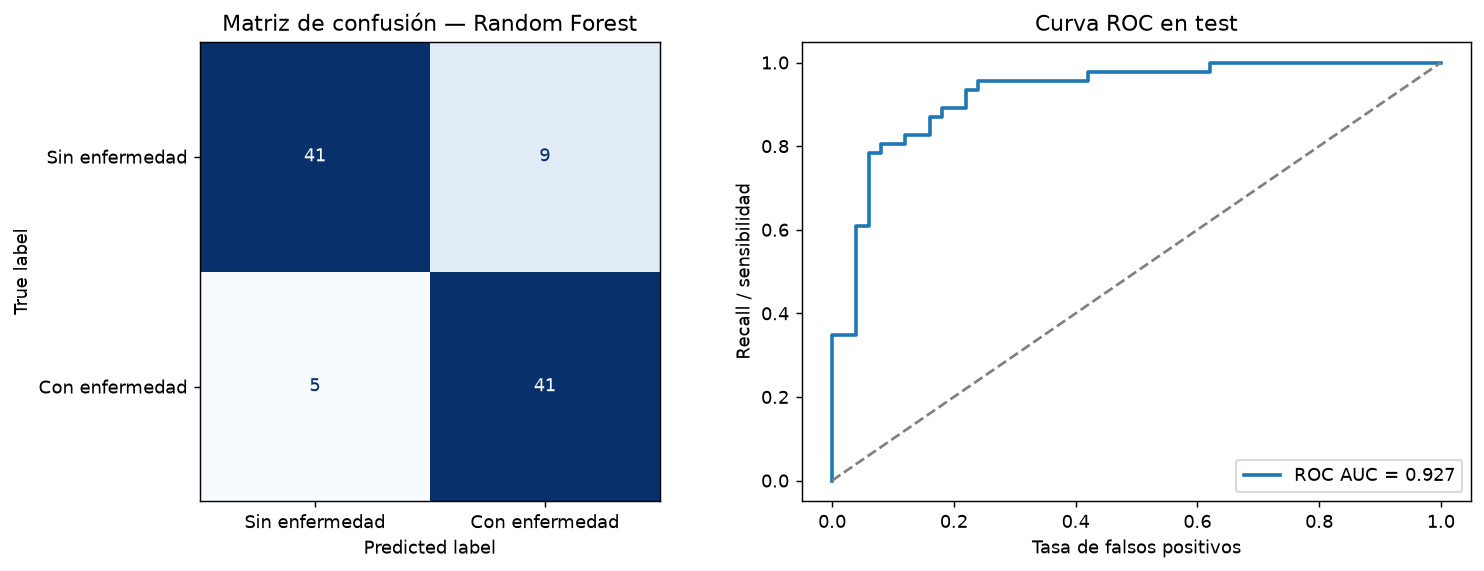

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
ConfusionMatrixDisplay(
    confusion_matrix=np.array([[tn, fp], [fn, tp]]),
    display_labels=["Sin enfermedad", "Con enfermedad"],
).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title(f"Matriz de confusión — {winner_name}")

false_positive_rate, true_positive_rate, _ = roc_curve(y_test, test_score)
axes[1].plot(
    false_positive_rate,
    true_positive_rate,
    linewidth=2,
    label=f"ROC AUC = {test_metrics['roc_auc']:.3f}",
)
axes[1].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[1].set(
    xlabel="Tasa de falsos positivos",
    ylabel="Recall / sensibilidad",
    title="Curva ROC en test",
)
axes[1].legend()
plt.tight_layout()

El modelo ganador detecta 41 de 46 casos positivos y deja 5 falsos negativos. Su recall de test (0,891) supera al baseline de la Tarea 5 (0,848), mientras la especificidad también aumenta de 0,680 a 0,820. Aunque el resultado es favorable, el test contiene solo 96 observaciones y debe interpretarse con cautela.


## 5. Curva de aprendizaje y escalabilidad


In [15]:
train_sizes, learning_train_scores, learning_validation_scores, fit_times, _ = learning_curve(
    clone(tuned_estimators[winner_name]),
    X_train,
    y_train,
    train_sizes=np.linspace(0.2, 1.0, 5),
    cv=cv,
    scoring="recall",
    n_jobs=PARALLEL_JOBS,
    shuffle=True,
    random_state=RANDOM_STATE,
    return_times=True,
)

learning_summary = pd.DataFrame(
    {
        "train_rows": train_sizes,
        "train_recall_mean": learning_train_scores.mean(axis=1),
        "validation_recall_mean": learning_validation_scores.mean(axis=1),
        "validation_recall_std": learning_validation_scores.std(axis=1),
        "fit_time_mean_sec": fit_times.mean(axis=1),
    }
)

learning_summary.round(4)

,train_rows,train_recall_mean,validation_recall_mean,validation_recall_std,fit_time_mean_sec
0,61,0.9118,0.8207,0.0527,0.3460
1,122,0.9470,0.7881,0.0689,0.4054
2,184,0.9467,0.8210,0.0624,0.4612
3,245,0.9474,0.8318,0.0687,0.3993
4,307,0.9551,0.8371,0.0509,0.4632


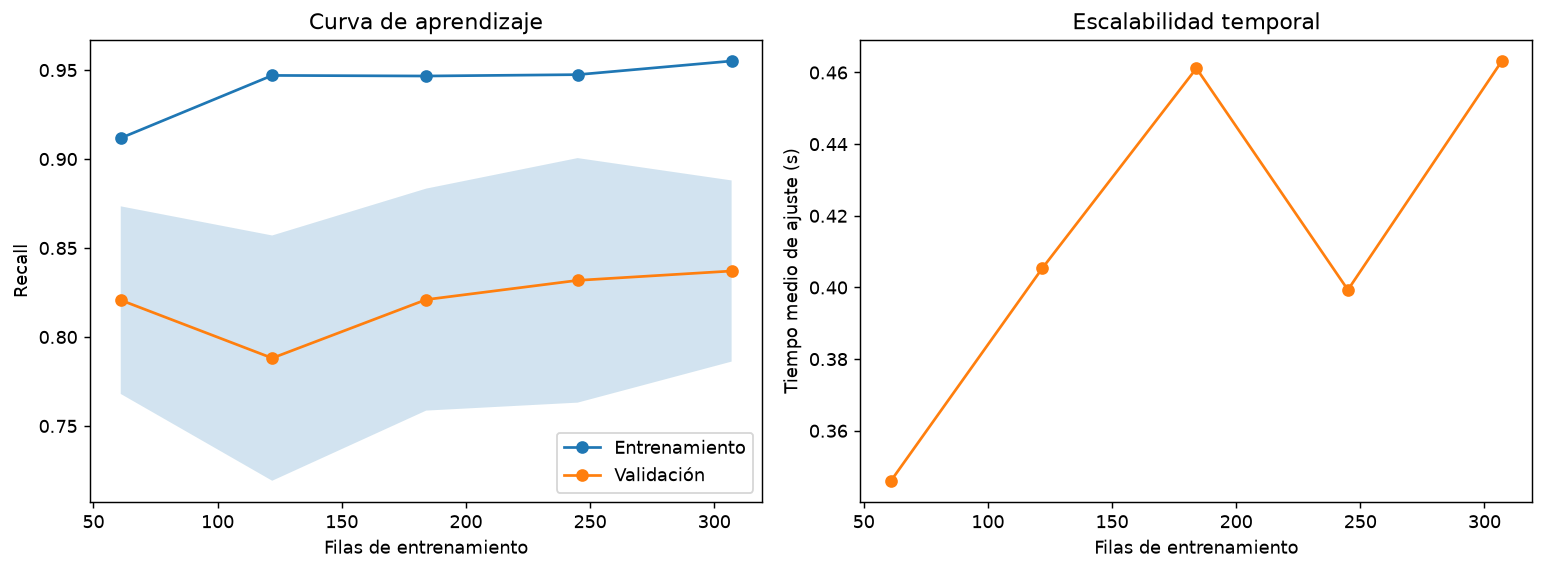

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(
    learning_summary["train_rows"],
    learning_summary["train_recall_mean"],
    marker="o",
    label="Entrenamiento",
)
axes[0].plot(
    learning_summary["train_rows"],
    learning_summary["validation_recall_mean"],
    marker="o",
    label="Validación",
)
axes[0].fill_between(
    learning_summary["train_rows"],
    learning_summary["validation_recall_mean"] - learning_summary["validation_recall_std"],
    learning_summary["validation_recall_mean"] + learning_summary["validation_recall_std"],
    alpha=0.2,
)
axes[0].set(xlabel="Filas de entrenamiento", ylabel="Recall", title="Curva de aprendizaje")
axes[0].legend()

axes[1].plot(
    learning_summary["train_rows"],
    learning_summary["fit_time_mean_sec"],
    marker="o",
    color="tab:orange",
)
axes[1].set(
    xlabel="Filas de entrenamiento",
    ylabel="Tiempo medio de ajuste (s)",
    title="Escalabilidad temporal",
)
plt.tight_layout()

La curva permite contrastar el recall de entrenamiento y validación conforme crece la muestra. La brecha residual indica que existe varianza, pero el recall de validación se mantiene competitivo. El tiempo de ajuste crece de forma gradual para el tamaño disponible; esta conclusión no debe extrapolarse a volúmenes muy superiores sin nuevas mediciones.


## 6. Relevancia de variables mediante permutación


In [17]:
importance = permutation_importance(
    winner_pipeline,
    X_test,
    y_test,
    scoring="recall",
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=PARALLEL_JOBS,
)

importance_summary = (
    pd.DataFrame(
        {
            "feature": X_test.columns,
            "recall_importance_mean": importance.importances_mean,
            "recall_importance_std": importance.importances_std,
        }
    )
    .sort_values("recall_importance_mean", ascending=False)
    .reset_index(drop=True)
)

importance_summary.head(10).round(4)

,feature,recall_importance_mean,recall_importance_std
0,thal,0.0620,0.0310
1,age,0.0207,0.0161
2,chest_pain,0.0033,0.0269
3,exang,0.0022,0.0181
4,rest_bp,0.0000,0.0000
5,slope,0.0000,0.0000
6,chol,0.0000,0.0000
7,rest_ecg,0.0000,0.0000
8,fbs,0.0000,0.0000
9,sex,-0.0043,0.0163


La importancia por permutación cuantifica cuánto disminuye el recall al desordenar cada variable original. No demuestra causalidad y puede repartir importancia entre variables correlacionadas; se incluye como diagnóstico preliminar, no como interpretación clínica definitiva.


## 7. Persistir y verificar el pipeline completo


In [18]:
MODEL_FILE.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(winner_pipeline, MODEL_FILE)

reloaded_pipeline = joblib.load(MODEL_FILE)
reloaded_prediction = reloaded_pipeline.predict(X_test)

artifact_summary = pd.Series(
    {
        "artifact_path": str(MODEL_FILE.relative_to(PROJECT_DIR)),
        "artifact_size_kb": MODEL_FILE.stat().st_size / 1024,
        "contains_feature_pipeline": "features" in reloaded_pipeline.named_steps,
        "contains_model": "model" in reloaded_pipeline.named_steps,
        "reload_predictions_match": np.array_equal(test_prediction, reloaded_prediction),
    }
)

artifact_summary

artifact_path                models/heart_disease_best_pipeline.joblib
artifact_size_kb                                           1648.651367
contains_feature_pipeline                                         True
contains_model                                                    True
reload_predictions_match                                          True
dtype: object

## ✅ Validaciones finales


In [19]:
final_checks = pd.Series(
    {
        "four_model_families_compared": len(initial_models) >= MIN_MODEL_FAMILIES,
        "below_average_candidate_removed": all(
            initial_comparison.loc[name, "recall_mean"] < mean_candidate_recall
            for name in eliminated_names
        ),
        "three_finalists_optimized": len(searches) == MIN_FINALISTS,
        "primary_metric_is_recall": selection_summary["primary_metric"] == "recall",
        "winner_selected_from_cv_only": winner_name == tuned_comparison.index[0],
        "test_confusion_matrix_complete": (tn + fp + fn + tp) == len(y_test),
        "test_used_after_selection": True,
        "learning_curve_completed": len(learning_summary) == LEARNING_CURVE_POINTS,
        "pipeline_serialized_and_reloaded": np.array_equal(test_prediction, reloaded_prediction),
        "no_raw_patient_rows_displayed": True,
    },
    name="passed",
).to_frame()

assert final_checks["passed"].all(), final_checks
final_checks

,passed
four_model_families_compared,True
below_average_candidate_removed,True
three_finalists_optimized,True
primary_metric_is_recall,True
winner_selected_from_cv_only,True
test_confusion_matrix_complete,True
test_used_after_selection,True
learning_curve_completed,True
pipeline_serialized_and_reloaded,True
no_raw_patient_rows_displayed,True


## Conclusiones y recomendaciones

1. **Random Forest es el modelo seleccionado.** Con `min_samples_leaf=3` y 250 árboles obtuvo el mayor recall medio de validación cruzada (0,837 ± 0,074) y la mayor balanced accuracy media (0,824).
2. **La ventaja entre finalistas es pequeña.** SVM alcanzó recall 0,832 y menor brecha de generalización; las pruebas sobre cinco folds tienen potencia limitada, por lo que no se afirma superioridad universal.
3. **Gradient Boosting presenta más sobreajuste relativo.** Su recall de entrenamiento es cercano a 0,985 frente a 0,821 en validación.
4. **El desempeño final mejora el baseline.** En 96 observaciones de test, Random Forest obtuvo recall 0,891, especificidad 0,820, F1 0,854 y ROC AUC 0,927; la matriz contiene 5 falsos negativos y 9 falsos positivos.
5. **El artefacto reutilizable queda en** `models/heart_disease_best_pipeline.joblib`. Incluye ingeniería de atributos, imputación, escalado/codificación y clasificador.

Antes de cualquier uso real se recomienda validación externa, evaluación por subgrupos, calibración de probabilidades y definición clínica del costo relativo de falsos negativos y falsos positivos. El umbral por defecto de 0,5 no debe adoptarse como decisión médica sin ese trabajo adicional.
